Dataset:
                  Name  Maths  Physics  Chemistry  English
0           Student_1     40       49         52       86
1           Student_2     63       36         52       72
2           Student_3     51       47         76       67
3           Student_4     54       82         69       83
4           Student_5     80       36         77       31
...               ...    ...      ...        ...      ...
99995   Student_99996     51       91         99       88
99996   Student_99997     68       57         38       74
99997   Student_99998     59       77         31       39
99998   Student_99999     72       97         94       99
99999  Student_100000     68       39         86       34

[100000 rows x 5 columns]

Updated Dataset:
                  Name  Maths  Physics  Chemistry  English  Total  Percentage  \
0           Student_1     40       49         52       86    227       56.75   
1           Student_2     63       36         52       72    223       55.75   
2       

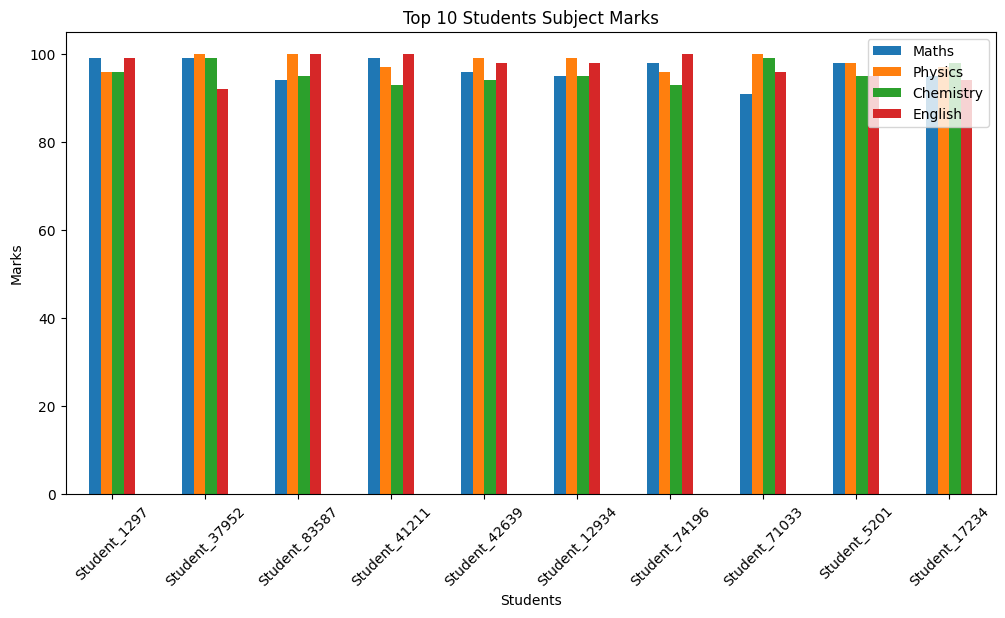

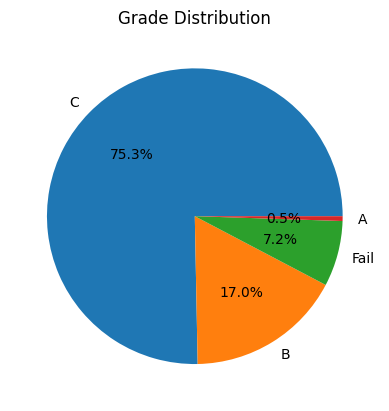

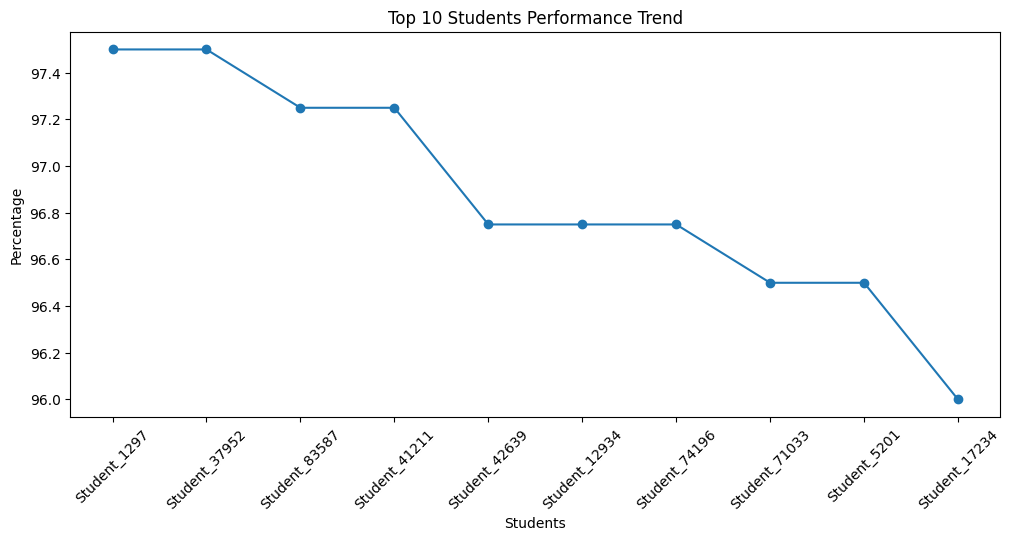

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel dataset
df = pd.read_excel("C:\\Users\\RISHABH JAIN\\Downloads\\students_100k.xlsx")   

# Display dataset
print("Dataset:\n", df)

# Calculate Total and Percentage
df['Total'] = df[['Maths', 'Physics', 'Chemistry', 'English']].sum(axis=1)
df['Percentage'] = df['Total'] / 4

# Assign Grades
def grade(p):
    if p >= 90:
        return 'A'
    elif p >= 75:
        return 'B'
    elif p >= 50:
        return 'C'
    else:
        return 'Fail'

df['Grade'] = df['Percentage'].apply(grade)

print("\nUpdated Dataset:\n", df)

# Topper
topper = df.loc[df['Percentage'].idxmax()]
print("\nTopper:\n", topper)

# Failed students
failed = df[df['Grade'] == 'Fail']
print("\nFailed Students:\n", failed)

# ------------------ VISUALIZATION ------------------

# Get Top 10 students based on Percentage
top10 = df.sort_values(by='Percentage', ascending=False).head(10)

# ------------------ BAR CHART ------------------

top10.set_index('Name')[['Maths', 'Physics', 'Chemistry', 'English']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Top 10 Students Subject Marks")
plt.xlabel("Students")
plt.ylabel("Marks")

plt.xticks(rotation=45)

plt.show()

# Pie chart
grade_counts = df['Grade'].value_counts()
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%')
plt.title("Grade Distribution")
plt.show()

# Line graph
plt.figure(figsize=(12,5))

plt.plot(
    top10['Name'],
    top10['Percentage'],
    marker='o'
)

plt.title("Top 10 Students Performance Trend")
plt.xlabel("Students")
plt.ylabel("Percentage")

plt.xticks(rotation=45)

plt.show()